## **Importacion de librerias**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Carga de los datos**

In [3]:
df = pd.read_csv('../datos/brutos/train.csv', sep=',', encoding='latin-1', low_memory=False)

## EDA

 **Conocer los datos**

In [4]:
df.shape

(2965, 26)

In [5]:
df.head()

,id,FRAUDE,VALOR,HORA_AUX,Dist_max_NAL,Canal1,FECHA,COD_PAIS,CANAL,DIASEM,...,INGRESOS,EGRESOS,NROPAISES,Dist_Sum_INTER,Dist_Mean_INTER,Dist_Max_INTER,NROCIUDADES,Dist_Mean_NAL,Dist_HOY,Dist_sum_NAL
0,9000000001,1,0.0,13,659.13,ATM_INT,20150501,US,ATM_INT,5,...,1200000.0,1200000.0,1,NaN,NaN,NaN,6,474.94,4552.41,5224.36
1,9000000002,1,0.0,17,594.77,ATM_INT,20150515,US,ATM_INT,5,...,5643700.0,500000.0,1,NaN,NaN,NaN,5,289.99,4552.41,2029.90
2,9000000003,1,0.0,13,659.13,ATM_INT,20150501,US,ATM_INT,5,...,1200000.0,1200000.0,1,NaN,NaN,NaN,6,474.94,4552.41,5224.36
3,9000000004,1,0.0,13,659.13,ATM_INT,20150501,US,ATM_INT,5,...,1200000.0,1200000.0,1,NaN,NaN,NaN,6,474.94,4552.41,5224.36
4,9000000005,1,0.0,0,1.00,ATM_INT,20150510,CR,ATM_INT,0,...,0.0,0.0,1,NaN,NaN,NaN,1,NaN,1482.35,1.00


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2965 entries, 0 to 2964
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               2965 non-null   int64  
 1   FRAUDE           2965 non-null   int64  
 2   VALOR            2965 non-null   float64
 3   HORA_AUX         2965 non-null   int64  
 4   Dist_max_NAL     2965 non-null   float64
 5   Canal1           2965 non-null   object 
 6   FECHA            2965 non-null   int64  
 7   COD_PAIS         2965 non-null   object 
 8   CANAL            2965 non-null   object 
 9   DIASEM           2965 non-null   int64  
 10  DIAMES           2965 non-null   int64  
 11  FECHA_VIN        2941 non-null   float64
 12  OFICINA_VIN      2941 non-null   float64
 13  SEXO             2910 non-null   object 
 14  SEGMENTO         2941 non-null   object 
 15  EDAD             2941 non-null   float64
 16  INGRESOS         2941 non-null   float64
 17  EGRESOS       

In [8]:
df.isnull().sum()   

id                    0
FRAUDE                0
VALOR                 0
HORA_AUX              0
Dist_max_NAL          0
Canal1                0
FECHA                 0
COD_PAIS              0
CANAL                 0
DIASEM                0
DIAMES                0
FECHA_VIN            24
OFICINA_VIN          24
SEXO                 55
SEGMENTO             24
EDAD                 24
INGRESOS             24
EGRESOS              24
NROPAISES             0
Dist_Sum_INTER     1547
Dist_Mean_INTER    1547
Dist_Max_INTER     1547
NROCIUDADES           0
Dist_Mean_NAL       457
Dist_HOY              0
Dist_sum_NAL          0
dtype: int64

In [9]:
# elimar del df las columnas hora_aux y fecha
df = df.drop(columns=['HORA_AUX', 'FECHA'])

In [10]:
df_sin_duplicados = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(7)

In [12]:
df['FRAUDE'].value_counts()

FRAUDE
0    2234
1     731
Name: count, dtype: int64

In [13]:
df['SEXO'].value_counts()

SEXO
M    1472
F    1438
Name: count, dtype: int64

In [14]:
df['SEGMENTO'].value_counts()

SEGMENTO
Personal Plus    1527
Preferencial      958
Personal          174
Emprendedor       159
PYME              119
Empresarial         4
Name: count, dtype: int64

In [15]:
df['CANAL'].value_counts()

CANAL
MCI        1200
POS        1129
ATM_INT     636
Name: count, dtype: int64

In [16]:
df['Canal1'].value_counts()

Canal1
POS        2329
ATM_INT     636
Name: count, dtype: int64

In [17]:
df['COD_PAIS'].value_counts().nunique()


17

**Converción tipo de dato object a categorica**

In [ ]:
df['FRAUDE'] = df['FRAUDE'].astype('category')
df['Canal1'] = df['Canal1'].astype('category')
df['SEXO'] = df['SEXO'].astype('category')
df['SEGMENTO'] = df['SEGMENTO'].astype('category')
df['COD_PAIS'] = df['COD_PAIS'].astype('category')

In [19]:
# imputacion de la valiable Sexo con la moda por F
df.loc[:, 'SEXO'] = df['SEXO'].fillna('F')

In [20]:
# imputación de la variable Segmento con personal plus
df["SEGMENTO"] = df["SEGMENTO"].fillna(df["SEGMENTO"].mode()[0]) 


In [22]:
# convertir las columnas FECHA_VIN a tipo fecha y hora
df['FECHA_VIN'] = pd.to_datetime(df['FECHA_VIN'], format='%Y-%m-%d', errors='coerce')


In [23]:
# imputacion de la variable FECHA_VIN con la fecha 2020-01-01
df.loc[:, 'FECHA_VIN'] = df['FECHA_VIN'].fillna(pd.to_datetime('2020-01-01', format='%Y-%m-%d'))

**Variables numericas**

In [24]:
df[['EDAD', 'INGRESOS', 'EGRESOS', 'OFICINA_VIN', 'Dist_Mean_NAL']].describe()

,EDAD,INGRESOS,EGRESOS,OFICINA_VIN,Dist_Mean_NAL
count,2941.000000,2.941000e+03,2.941000e+03,2941.000000,2508.000000
mean,40.010541,1.449104e+07,8.506309e+06,416.426386,196.589282
std,12.976492,5.637311e+07,6.179161e+07,290.263484,192.026206
min,0.000000,0.000000e+00,0.000000e+00,1.000000,4.480000
25%,31.000000,2.500000e+06,5.000000e+05,168.000000,60.800000
50%,38.000000,5.800000e+06,1.800000e+06,360.000000,127.700000
75%,47.000000,1.274000e+07,4.500000e+06,659.000000,269.082500
max,133.000000,1.940070e+09,1.600000e+09,967.000000,1217.570000


In [25]:
# imputacion de valores nulos en las variables nuericas con la mediana
df['EDAD'] = df['EDAD'].fillna(df['EDAD'].median())
df['INGRESOS'] = df['INGRESOS'].fillna(df['INGRESOS'].median())
df['EGRESOS'] = df['EGRESOS'].fillna(df['EGRESOS'].median())
df['OFICINA_VIN'] = df['OFICINA_VIN'].fillna(df['OFICINA_VIN'].median())
df['Dist_Mean_NAL'] = df['Dist_Mean_NAL'].fillna(df['Dist_Mean_NAL'].median())

**Datos limpios**
Nota: aun mo sabemos para que no serviran las variables (Dist_Sum_INTER, Dist_Mean_INTER, Dist_Max_INTER), cada uno con 1547 datos nulos.

In [27]:
df.isnull().sum()

id                    0
FRAUDE                0
VALOR                 0
Dist_max_NAL          0
Canal1                0
COD_PAIS              0
CANAL                 0
DIASEM                0
DIAMES                0
FECHA_VIN             0
OFICINA_VIN           0
SEXO                  0
SEGMENTO              0
EDAD                  0
INGRESOS              0
EGRESOS               0
NROPAISES             0
Dist_Sum_INTER     1547
Dist_Mean_INTER    1547
Dist_Max_INTER     1547
NROCIUDADES           0
Dist_Mean_NAL         0
Dist_HOY              0
Dist_sum_NAL          0
dtype: int64

**Gráficos de varaibles categoricas**

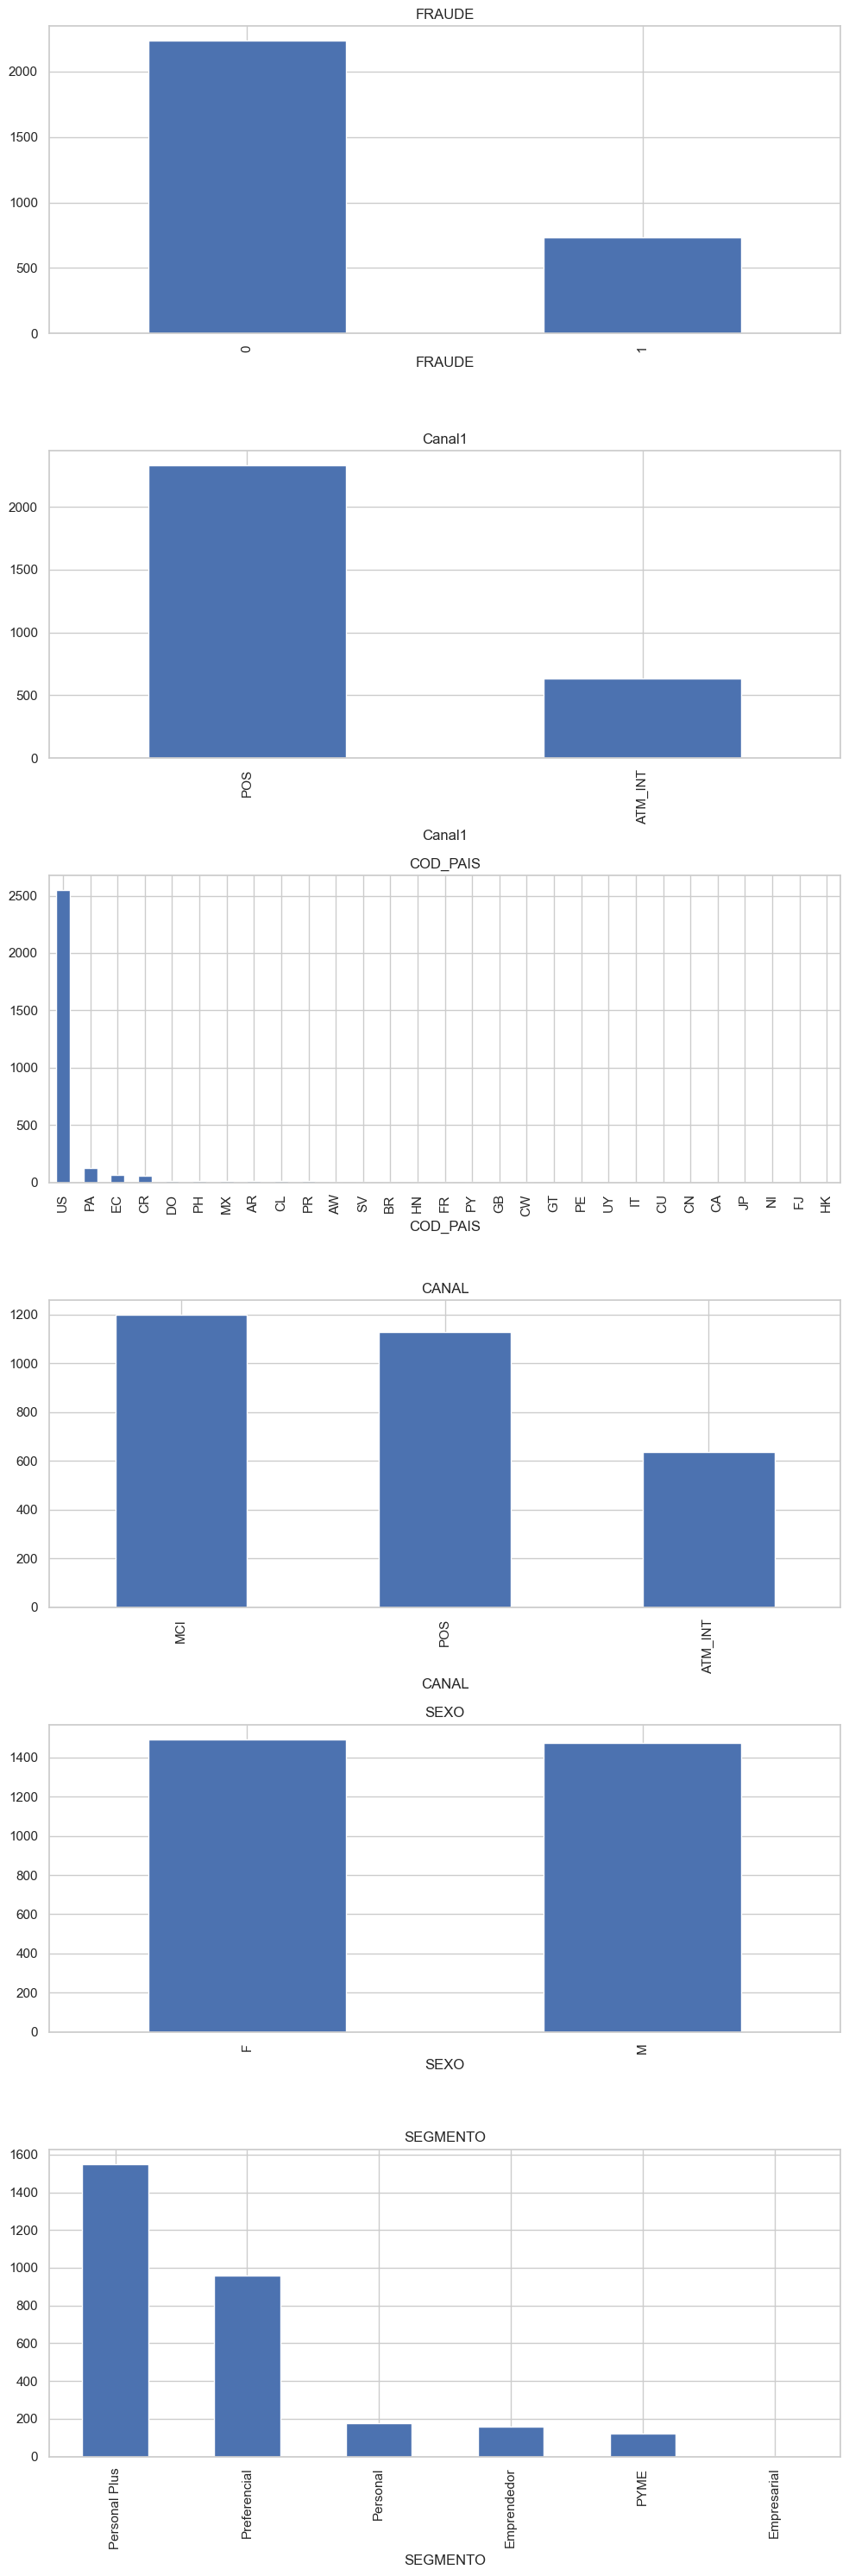

In [ ]:
# genera un grafico con las variables categoricas y su distribucion de valores
categoricas = df.select_dtypes(include=["object", "category"]).columns

fig, axes = plt.subplots(len(categoricas), 1, figsize=(10, 5 * len(categoricas)))
for ax, col in zip(axes, categoricas):
    df[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Gráficos de variables númericas**

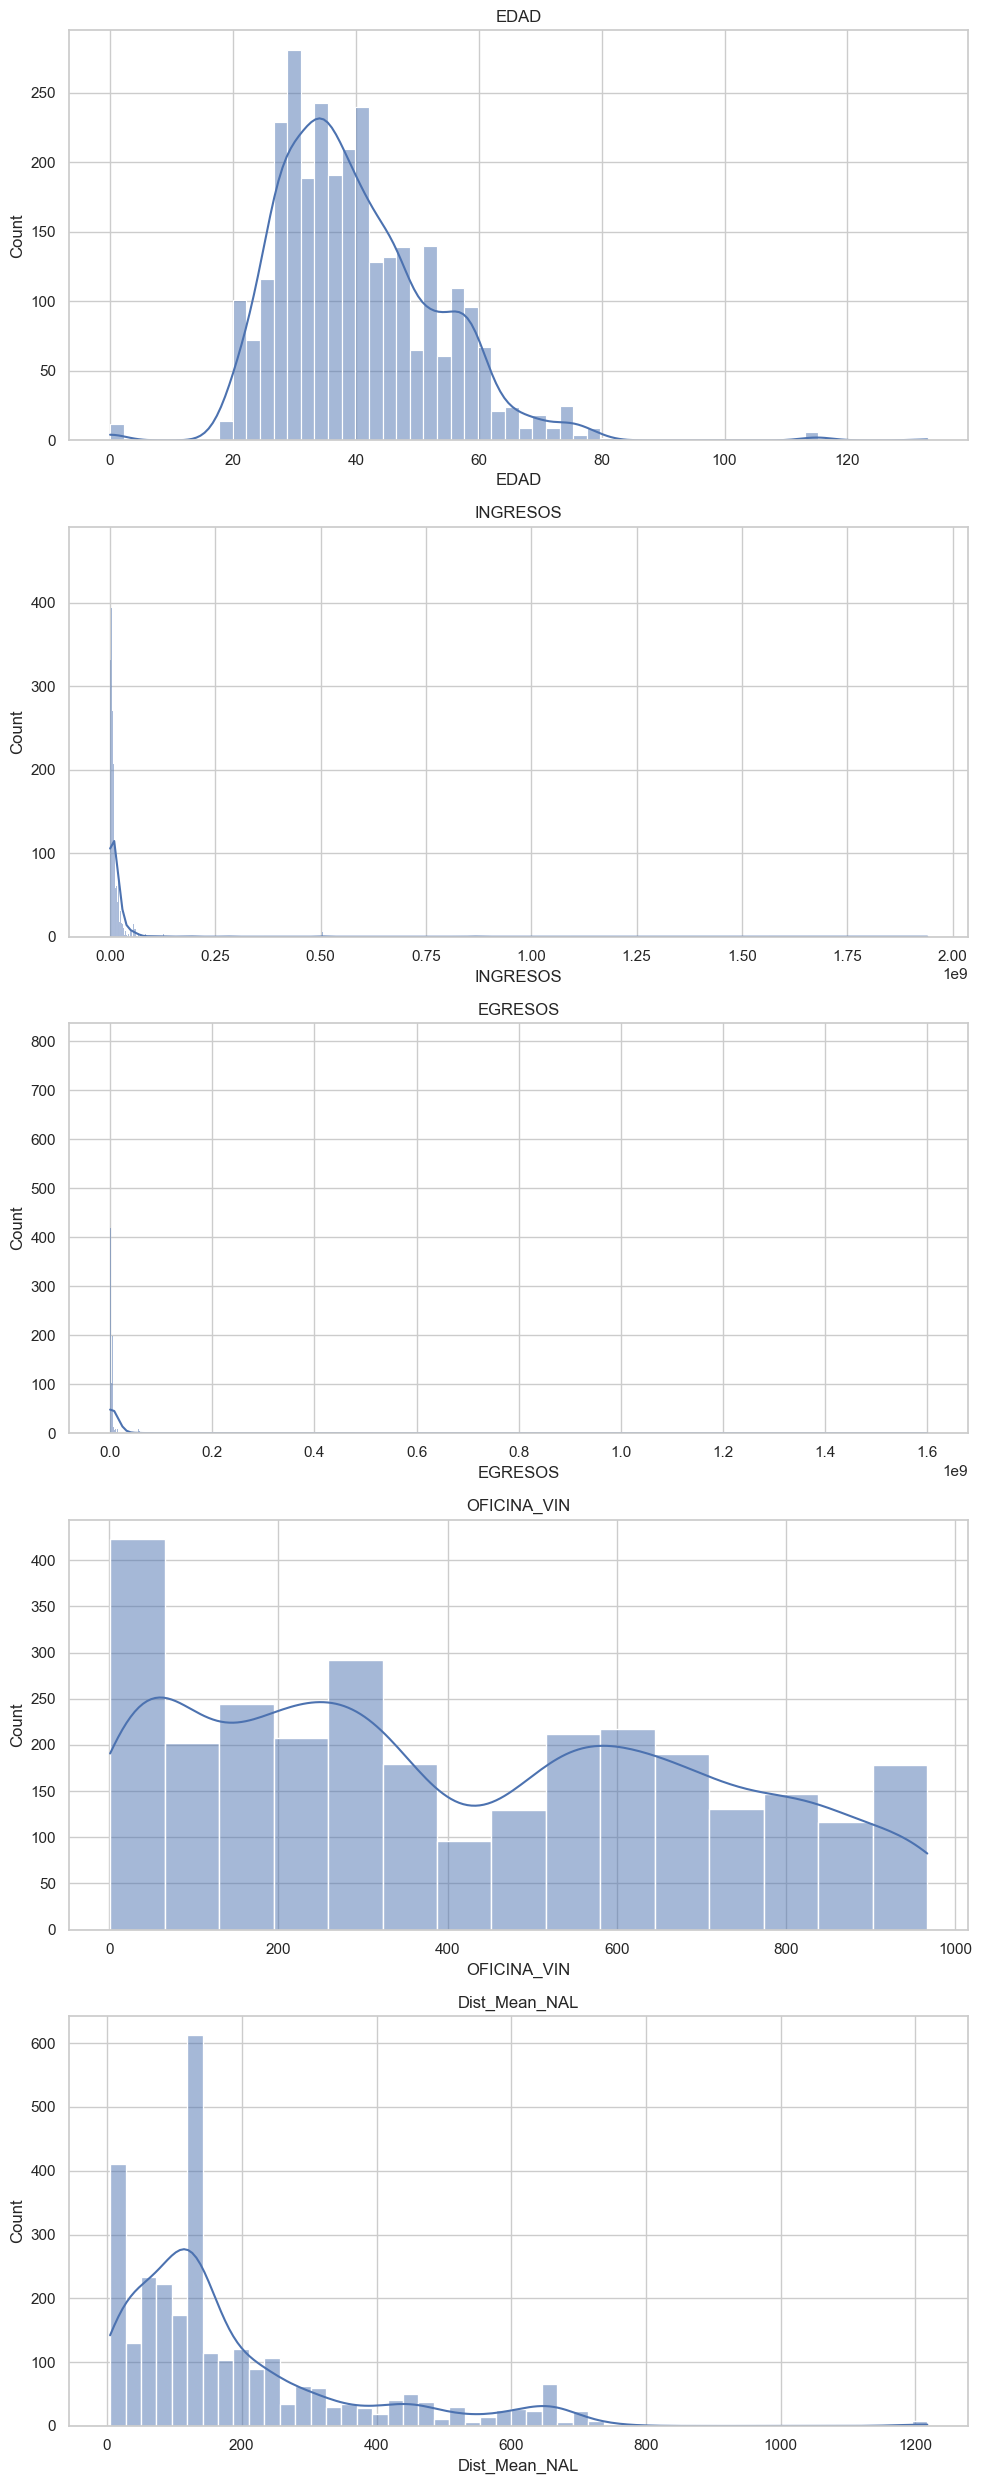

In [ ]:
# genera un grafico con las variables numericas analizadas 
# (edad, ingresos, egresos, oficina_vin, dist_mean_nal)y su distribucion de valores
numericas = df[['EDAD', 'INGRESOS', 'EGRESOS', 'OFICINA_VIN', 'Dist_Mean_NAL']].columns 
fig, axes = plt.subplots(len(numericas), 1, figsize=(10, 5 * len(numericas)))
for ax, col in zip(axes, numericas):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Analisis Bivariado**

Fraude con categoricas

In [32]:
pd.crosstab(df['FRAUDE'], df['SEXO'], normalize='index')*100

SEXO,F,M
FRAUDE,,
0,48.701880,51.298120
1,55.403557,44.596443


In [34]:
pd.crosstab(df['FRAUDE'], df['SEGMENTO'], normalize='index')*100

SEGMENTO,Emprendedor,Empresarial,PYME,Personal,Personal Plus,Preferencial
FRAUDE,,,,,,
0,5.058192,0.179051,5.102954,4.341987,48.478066,36.839749
1,6.292750,0.000000,0.683995,10.533516,64.021888,18.467852


In [ ]:
pd.crosstab(df['FRAUDE'], df['CANAL'], normalize='index')*100

CANAL,ATM_INT,MCI,POS
FRAUDE,,,
0,9.131603,47.090421,43.777977
1,59.097127,20.246238,20.656635


In [61]:
pd.crosstab(df['FRAUDE'], df['Canal1'], normalize='index')*100

Canal1,ATM_INT,POS
FRAUDE,,
0,9.131603,90.868397
1,59.097127,40.902873


In [66]:
tabla1_cod = pd.crosstab(df['FRAUDE'], df['COD_PAIS'], normalize='index')*100
tabla1_cod.sort_values(by=1, axis=1, ascending=False, inplace=True)
tabla1_cod

COD_PAIS,US,EC,CR,PA,PH,MX,CL,SV,HN,BR,...,AR,CA,FJ,CU,AW,JP,PR,PE,PY,UY
FRAUDE,,,,,,,,,,,,,,,,,,,,,
0,91.047449,0.671441,0.089526,4.789615,0.000000,0.089526,0.179051,0.000000,0.000000,0.044763,...,0.671441,0.089526,0.044763,0.089526,0.447628,0.089526,0.537153,0.134288,0.268577,0.134288
1,70.451436,7.523940,7.387141,2.599179,2.051984,1.778386,1.231190,1.094391,0.957592,0.957592,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Fraude con Númericas

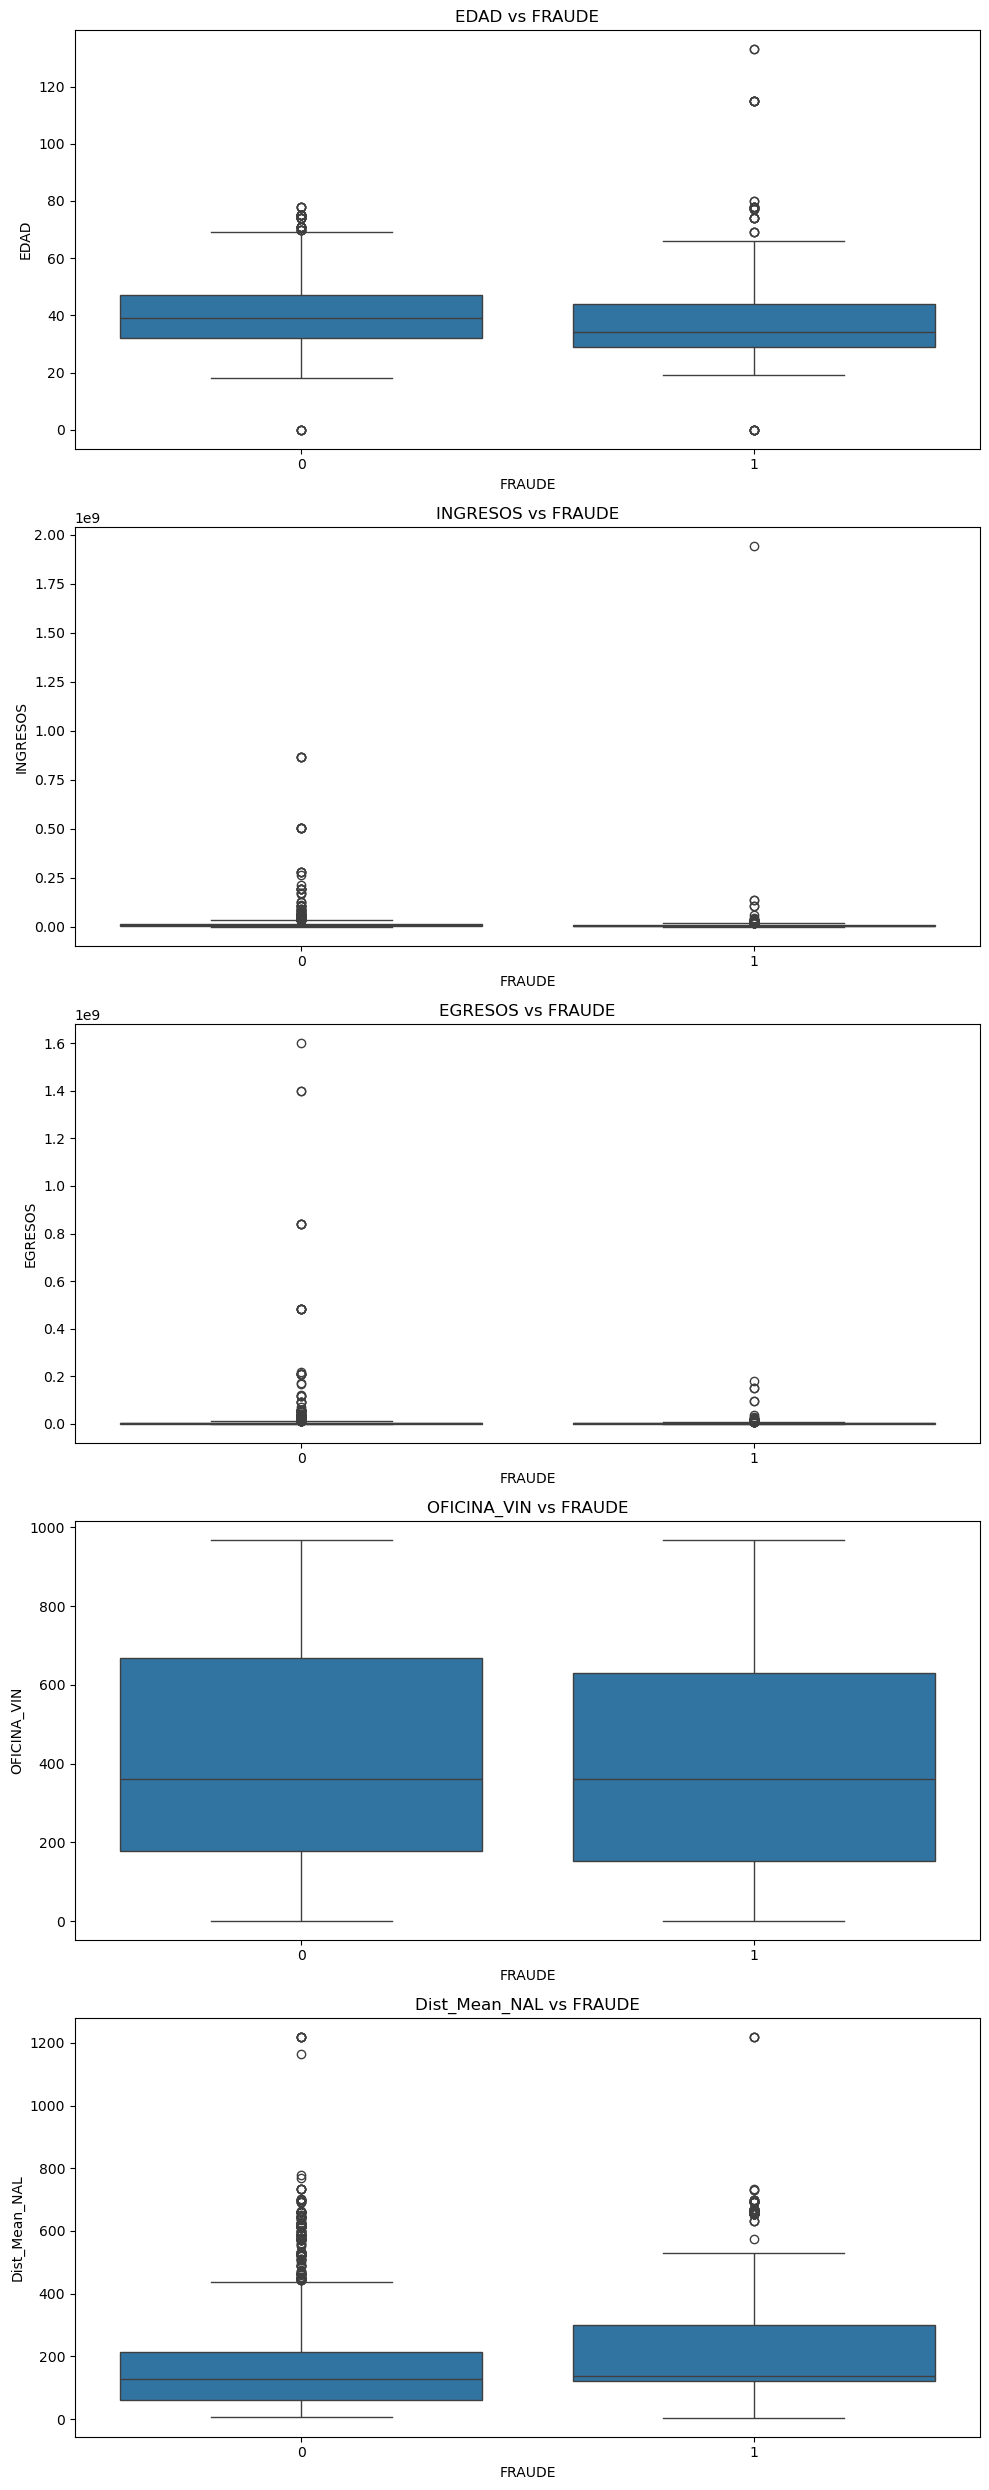

In [71]:
# Variables numéricas (excepto la variable objetivo)
numericas = numericas = df[['EDAD', 'INGRESOS', 'EGRESOS', 'OFICINA_VIN', 'Dist_Mean_NAL']].columns 

# Crear la figura
fig, axes = plt.subplots(len(numericas), 1, figsize=(10, 5 * len(numericas)))

# Graficar cada variable vs FRAUDE
for ax, col in zip(axes, numericas):
    sns.boxplot(data=df, x="FRAUDE", y=col, ax=ax)
    ax.set_title(f"{col} vs FRAUDE")

plt.tight_layout()
plt.show()